In [10]:
!pip3 install mediapipe

import os, math, warnings
from collections import Counter

import numpy  as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import mediapipe as mp
from mediapipe.tasks                         import python as mp_tasks
from mediapipe.tasks.python                  import vision as mp_vision
from mediapipe.tasks.python.core             import base_options as bo
from mediapipe.tasks.python.vision           import PoseLandmarker, PoseLandmarkerOptions, RunningMode
from mediapipe import Image, ImageFormat

warnings.filterwarnings("ignore")

print(f"MediaPipe  : {mp.__version__}")
print(f"OpenCV     : {cv2.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")


MediaPipe  : 0.10.35
OpenCV     : 4.10.0
NumPy      : 2.1.3
Pandas     : 2.2.3


In [11]:
MODEL_PATH = "pose_landmarker_lite.task"

if os.path.exists(MODEL_PATH):
    print("path exists")
else:
    print("Model either in wrong location, or model not yet downloaded")

path exists


In [12]:
# ── Configuration ─────────────────────────────────────────────────────────────
TRAIN_DIR  = "datasets"        # root folder: one sub-folder per class
IMG_EXTS   = {".jpg", ".jpeg", ".png", ".bmp", ".webp"} # set containing the allowed image file extensions
OUTPUT_CSV = "posture_detection.csv" # filename where the extracted landmarks will be saved as CSV
# ──────────────────────────────────────────────────────────────────────────────

def collect_images(root: str) -> list:
    """
    Walk `root` and return [{"path": ..., "label": ...}, ...].
    The sub-folder name is used as the class label.
    """
    records = []
    for label in sorted(os.listdir(root)):
        class_dir = os.path.join(root, label) # Build full path to the class folder (e.g., TRAIN/Tree)
        if not os.path.isdir(class_dir): # Skip anything that is not a directory (e.g., files)
            continue # Continue to the next item
        for fname in sorted(os.listdir(class_dir)): # Loop through files inside the class directory
            if os.path.splitext(fname)[1].lower() in IMG_EXTS: # Get file extension and check if it's an allowed image type
                # Add a dictionary to the list:
                # "path"  -> full image path
                # "label" -> class name (folder name)
                records.append({"path": os.path.join(class_dir, fname), "label": label})
    return records


image_records = collect_images(TRAIN_DIR) # Call the function to collect all dataset images
counts = Counter(r["label"] for r in image_records) # Count how many images belong to each label

print(f"Total images found: {len(image_records)}") # Print total number of images collected
for label, n in counts.items(): # Loop through each label and its count 
    print(f"  {label:15s}: {n} images") # Print label name (left aligned in 15 chars) and number of images

Total images found: 687
  good_posture   : 111 images
  leaning_forward: 136 images
  leaning_sideways: 110 images
  looking_down   : 109 images
  looking_up     : 100 images
  slouching      : 121 images


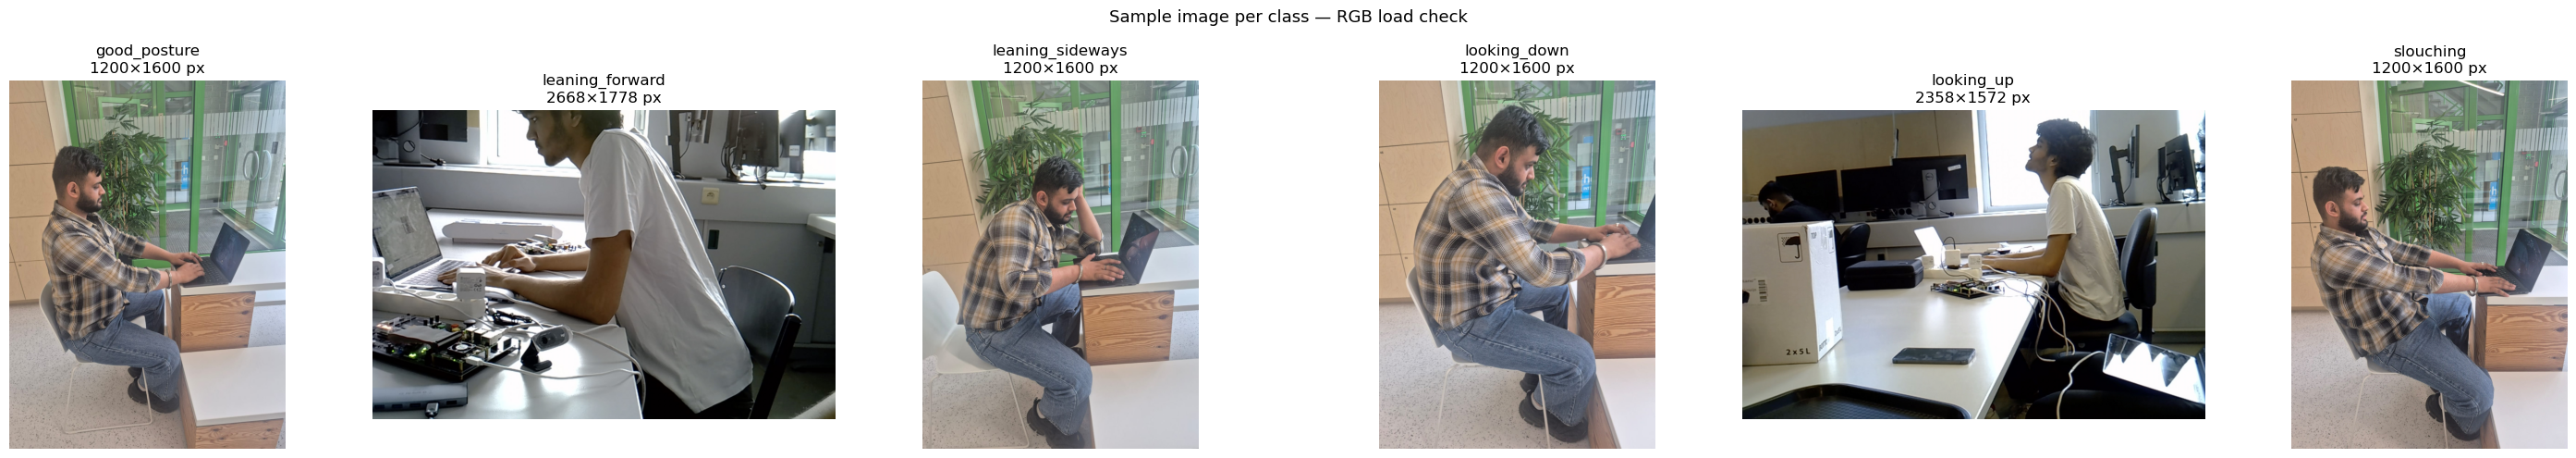

✅ If images appear above, loading is working correctly.


In [13]:
def load_rgb(path: str):
    """
    Read an image with OpenCV and convert BGR → RGB.
    OpenCV loads in BGR order; MediaPipe and matplotlib both expect RGB.
    Returns None if the file cannot be read.
    """
    # Load the image from disk using OpenCV
    # Result is a NumPy array in BGR color order
    # Returns None if file is missing or unreadable
    img_bgr = cv2.imread(path) 
    if img_bgr is None: # Check if image loading failed
        return None
    else:
        return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) # Convert image from BGR to RGB color format


classes = sorted(counts.keys()) # Get all class names from the counts dictionary

# Create a matplotlib figure with 1 row and one column per class
# figsize dynamically scales width depending on number of classes
fig, axes = plt.subplots(1, len(classes), figsize=(5 * len(classes), 5))

# Loop through each subplot axis and each class name together
for ax, cls in zip(axes, classes):
    # Find the FIRST image belonging to this class
    # next(...) stops at the first match (used as sample image)
    record = next(r for r in image_records if r["label"] == cls) #!
    # Load the image using the helper function above
    img    = load_rgb(record["path"])
    if img is None:
        # Show warning in subplot title
        ax.set_title(f"{cls}\n⚠ LOAD FAILED")
    else:
        ax.imshow(img)
        # Show class name + image resolution
        ax.set_title(f"{cls}\n{img.shape[1]}×{img.shape[0]} px")
    # Hide x/y axis ticks for cleaner display
    ax.axis("off")

# Add a main title above all subplots
plt.suptitle("Sample image per class — RGB load check", fontsize=13)
# Automatically adjust spacing to prevent overlap
plt.tight_layout()
# Render the figure to the screen
plt.show()
print("✅ If images appear above, loading is working correctly.")

In [14]:
options = PoseLandmarkerOptions(
    base_options = bo.BaseOptions(model_asset_path=MODEL_PATH), # Tell MediaPipe which model file to load
    running_mode = RunningMode.IMAGE, # Set processing mode to single images Other options: VIDEO, LIVE_STREAM
    num_poses = 1, # Detect at most ONE person per image (he will pick the person closest to the camera)
    min_pose_detection_confidence = 0.5, # Minimum confidence required to detect a pose at all
    min_pose_presence_confidence = 0.5, # Confidence threshold that a pose is actually present
    min_tracking_confidence = 0.5, # Used mainly for video tracking, but still required
    output_segmentation_masks = False, # Disable body segmentation masks. Saves memory and speeds up processing since you only need landmarks
)

# The landmarker is used as a context manager so it is properly closed on exit.
# We will open it once for the whole batch in Step 6.
print("✅ PoseLandmarkerOptions configured.")

✅ PoseLandmarkerOptions configured.


In [15]:
import cv2
import numpy as np

# Landmarks used for training
SELECTED_LANDMARKS = [
    0,      # Nose
    7, 8,   # Ears
    11, 12, # Shoulders
    23, 24
]

# Connections used for visualization
SELECTED_CONNECTIONS = [
    (11,12),    # shoulders

    (11,23),    # left upper arm
    (12,14),    # right upper arm

    (0,11),     # nose -> left shoulder
    (0,12),     # nose -> right shoulder

    (7,0),      # left ear -> nose
    (8,0),      # right ear -> nose
]

def draw_selected_landmarks(rgb_image, detection_result):
    annotated_image = np.copy(rgb_image)

    h, w, _ = annotated_image.shape

    for pose_landmarks in detection_result.pose_landmarks:

        # Draw connections
        for start_idx, end_idx in SELECTED_CONNECTIONS:

            start = pose_landmarks[start_idx]
            end = pose_landmarks[end_idx]

            x1, y1 = int(start.x * w), int(start.y * h)
            x2, y2 = int(end.x * w), int(end.y * h)

            cv2.line(
                annotated_image,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )

        # Draw landmarks
        for idx in SELECTED_LANDMARKS:

            lm = pose_landmarks[idx]

            x = int(lm.x * w)
            y = int(lm.y * h)

            cv2.circle(
                annotated_image,
                (x, y),
                5,
                (255, 0, 0),
                -1
            )

            cv2.putText(
                annotated_image,
                str(idx),
                (x + 5, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.4,
                (0, 255, 255),
                1
            )

    return annotated_image

I0000 00:00:1780654161.643051 4765522 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
W0000 00:00:1780654161.686105 4765529 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780654161.693802 4765527 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


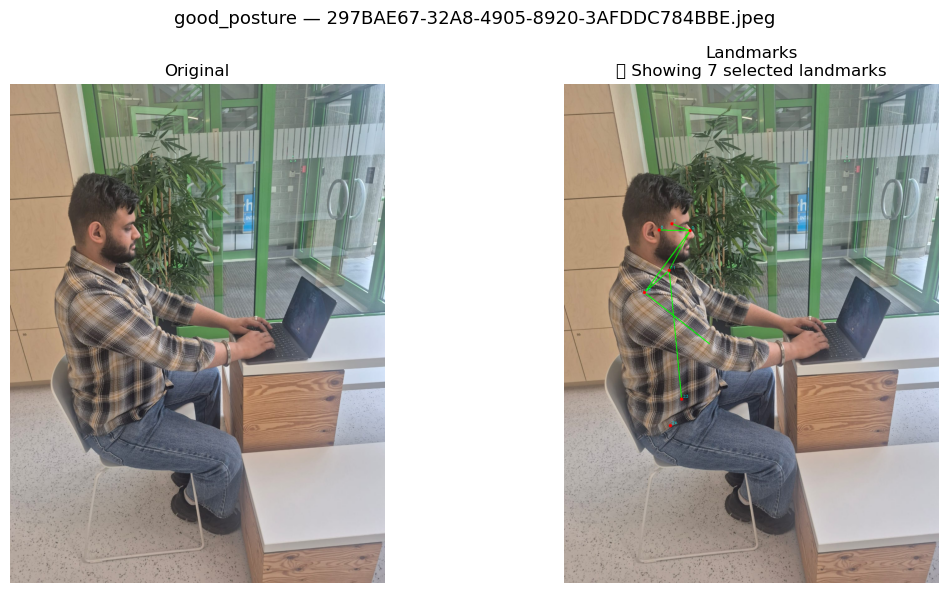

In [16]:
# Run on the first image as a visual sanity check
sample = image_records[0]

# Load image in RGB format using helper function
img    = load_rgb(sample["path"])

# Wrap the numpy array into MediaPipe Image object — required by the Tasks API
mp_img  = Image(image_format=ImageFormat.SRGB, data=img)

# Create pose detector using earlier configuration
with PoseLandmarker.create_from_options(options) as landmarker:
    result = landmarker.detect(mp_img) # Run pose detection on the image

if result.pose_landmarks:               # result.pose_landmarks is a list-of-lists (one entry per detected person)
    annotated =draw_selected_landmarks(img, result)  # [0] = first person
    status = f"✅ Showing {len(SELECTED_LANDMARKS)} selected landmarks"
else:
    annotated = img.copy()
    status = "⚠ No pose detected — try a different image"

# Create figure with 2 side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(annotated); axes[1].set_title(f"Landmarks\n{status}"); axes[1].axis("off")
plt.suptitle(f"{sample['label']} — {os.path.basename(sample['path'])}", fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
import math

SELECTED_LANDMARKS = [0, 7, 8, 11, 12, 23, 24]  # no elbows

def calculate_angle(p1, p2):
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    return math.degrees(math.atan2(dy, dx))

def extract_features(result, label):
    if not result.pose_landmarks:
        return None

    lms = result.pose_landmarks[0]
    row = {}

    # Raw midpoints
    ear_x      = (lms[7].x  + lms[8].x)  / 2
    ear_y      = (lms[7].y  + lms[8].y)  / 2
    shoulder_x = (lms[11].x + lms[12].x) / 2
    shoulder_y = (lms[11].y + lms[12].y) / 2
    hip_x      = (lms[23].x + lms[24].x) / 2
    hip_y      = (lms[23].y + lms[24].y) / 2

    # Normalization: nose=top(0), hip=bottom(1)
    y_top       = lms[0].y
    y_bottom    = hip_y
    x_ref       = hip_x
    body_height = (y_bottom - y_top) + 1e-6

    def norm_y(y): return (y - y_top)  / body_height
    def norm_x(x): return (x - x_ref) / body_height

    # Normalized landmark coordinates
    for idx in SELECTED_LANDMARKS:
        lm = lms[idx]
        row[f"lm{idx}_x"] = norm_x(lm.x)
        row[f"lm{idx}_y"] = norm_y(lm.y)
        row[f"lm{idx}_z"] = lm.z           # z unchanged

    # Normalized midpoints
    nose_xn     = norm_x(lms[0].x)
    nose_yn     = norm_y(lms[0].y)    # = 0.0
    ear_xn      = norm_x(ear_x)
    ear_yn      = norm_y(ear_y)
    shoulder_xn = norm_x(shoulder_x)
    shoulder_yn = norm_y(shoulder_y)
    hip_xn      = norm_x(hip_x)      # = 0.0
    hip_yn      = norm_y(hip_y)      # = 1.0

    # 4 angles
    row["head_angle"]     = calculate_angle((ear_xn,      ear_yn),
                                            (nose_xn,     nose_yn))
    row["neck_angle"]     = calculate_angle((shoulder_xn, shoulder_yn),
                                            (ear_xn,      ear_yn))
    row["torso_angle"]    = calculate_angle((hip_xn,      hip_yn),
                                            (shoulder_xn, shoulder_yn))
    row["shoulder_angle"] = calculate_angle(
        (norm_x(lms[11].x), norm_y(lms[11].y)),
        (norm_x(lms[12].x), norm_y(lms[12].y))
    )

    # 4 ratio features
    row["forward_lean"]         = nose_xn - shoulder_xn
    row["spine_curve"]          = (nose_xn - shoulder_xn) - (shoulder_xn - hip_xn)
    row["lateral_shift_norm"]   = shoulder_xn - hip_xn
    row["shoulder_height_diff"] = norm_y(lms[11].y) - norm_y(lms[12].y)

    row["label"] = label
    return row

print("Feature extraction ready")
print(f"7 landmarks × 3 = {7*3} coordinate features")
print("8 engineered features")
print("1 label")
print(f"Total columns = {7*3 + 8 + 1}")  # = 30

Feature extraction ready
7 landmarks × 3 = 21 coordinate features
8 engineered features
1 label
Total columns = 30


In [18]:
rows   = []       # List that will store one feature dictionary per successful image
failed = []       # List that will store paths of images that failed (no pose or load error)

# Open the landmarker ONCE outside the loop.
# Creating it inside the loop would reload the model weights on every image
# which is very slow. The context manager ensures the model is freed afterwards.
with PoseLandmarker.create_from_options(options) as landmarker: # "with" automatically cleans up resources when finished

    for i, record in enumerate(image_records, start=1): 
        path, label = record["path"], record["label"] # Extract image path and class label from record

        # 1. Load image
        img = load_rgb(path)
        if img is None:
            print(f"  [{i:4d}] ⚠ Could not load: {path}")
            failed.append(path)
            continue

        # 2. Convert numpy array to MediaPipe Image object
        mp_img = Image(image_format=ImageFormat.SRGB, data=img)

        # 3. Run pose detection
        result = landmarker.detect(mp_img)

        # 4. Extract features
        row = extract_features(result, label)
        if row is None:
            print(f"  [{i:4d}] ⚠ No pose detected: {path}")
            failed.append(path)
            continue

        rows.append(row)

        # Every 20 images (or last image), print progress
        if i % 20 == 0 or i == len(image_records): 
            print(f"  [{i:4d}/{len(image_records)}] ✓  rows so far: {len(rows)}")

print(f"\n✅ Done.  Successful: {len(rows)}  |  Failed: {len(failed)}")

I0000 00:00:1780654164.097575 4765571 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
W0000 00:00:1780654164.151247 4765574 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780654164.157024 4765577 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


  [  20/687] ✓  rows so far: 20
  [  40/687] ✓  rows so far: 40
  [  60/687] ✓  rows so far: 60
  [  80/687] ✓  rows so far: 80
  [ 100/687] ✓  rows so far: 100
  [ 120/687] ✓  rows so far: 120
  [ 140] ⚠ No pose detected: datasets/leaning_forward/Photo on 04-06-26 at 11.01 AM #6.jpg
  [ 160/687] ✓  rows so far: 159
  [ 180/687] ✓  rows so far: 179
  [ 195] ⚠ No pose detected: datasets/leaning_forward/Photo on 04-06-26 at 11.13 AM.jpg
  [ 200/687] ✓  rows so far: 198
  [ 205] ⚠ No pose detected: datasets/leaning_forward/Photo on 04-06-26 at 11.14 AM.jpg
  [ 220/687] ✓  rows so far: 217
  [ 231] ⚠ No pose detected: datasets/leaning_forward/Photo on 04-06-26 at 11.20 AM #2.jpg
  [ 240/687] ✓  rows so far: 236
  [ 241] ⚠ No pose detected: datasets/leaning_forward/Photo on 05-06-26 at 10.22 AM #4.jpg
  [ 243] ⚠ No pose detected: datasets/leaning_forward/Photo on 05-06-26 at 10.22 AM #6.jpg
  [ 244] ⚠ No pose detected: datasets/leaning_forward/Photo on 05-06-26 at 10.22 AM #7.jpg
  [ 247] ⚠

In [19]:
# Convert list of dictionaries (rows) into a pandas DataFrame
df = pd.DataFrame(rows)

# shuffle the dataset so that not every class is grouped together:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Shape:", df.shape) # Print dataset dimensions: (number_of_rows, number_of_columns)
print("\nSamples per class:")
print(df["label"].value_counts().to_string())
df.head()

Shape: (671, 30)

Samples per class:
label
leaning_forward     128
slouching           118
good_posture        111
leaning_sideways    109
looking_down        106
looking_up           99


,lm0_x,lm0_y,lm0_z,lm7_x,lm7_y,lm7_z,lm8_x,lm8_y,lm8_z,lm11_x,...,lm24_z,head_angle,neck_angle,torso_angle,shoulder_angle,forward_lean,spine_curve,lateral_shift_norm,shoulder_height_diff,label
0,0.817910,0.0,-0.202389,0.616890,-0.097226,-0.104819,0.567680,-0.055480,-0.337825,0.254434,...,-0.142134,18.696106,-43.694331,-71.253436,89.194207,0.561533,0.305155,0.256378,-0.276446,looking_down
1,0.645723,0.0,-0.037748,0.549217,-0.115302,0.101423,0.555956,-0.087757,-0.265461,0.352494,...,-0.202342,47.468662,-53.801401,-66.383148,61.552210,0.269398,-0.106928,0.376326,-0.087977,leaning_forward
2,0.014072,0.0,-0.091476,-0.068916,0.011547,0.007294,-0.074451,0.025478,-0.169915,-0.076511,...,-0.125495,-12.181848,-92.316502,-94.874270,51.269936,0.074912,0.135752,-0.060840,-0.039078,looking_up
3,0.255353,0.0,-0.462670,0.415025,0.083419,-0.505181,0.358145,0.002475,-0.293974,0.327309,...,0.146539,-161.878837,-73.693282,-64.998313,-106.861981,-0.030691,-0.316735,0.286044,0.272287,slouching
4,0.803548,0.0,-0.158835,0.683684,-0.125658,-0.005363,0.644134,-0.124790,-0.261838,0.444234,...,-0.161165,41.884749,-42.970442,-66.210278,159.651235,0.424482,0.045416,0.379066,-0.048339,leaning_sideways


In [21]:
df.to_csv(OUTPUT_CSV, index=False)   # index=False keeps row numbers out of the file

print(f"✅ Saved '{OUTPUT_CSV}'")
print(f"   Rows    : {len(df)}")
print(f"   Columns : {len(df.columns)}")


# Round-trip check: reload and verify shape matches
df_check = pd.read_csv(OUTPUT_CSV)
assert df_check.shape == df.shape, "Shape mismatch after reload!"
print("✅ CSV round-trip check passed.")

✅ Saved 'posture_detection.csv'
   Rows    : 671
   Columns : 30
✅ CSV round-trip check passed.
